In [1]:
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

TEST_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "Testing"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "resnet18_brain_tumor.pth"
)

RESULTS_FOLDER = (
    PROJECT_ROOT
    / "results"
)

RESULTS_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Testing folder:", TEST_DATA_PATH)
print("Model path:", MODEL_PATH)
print("Results folder:", RESULTS_FOLDER)

print("\nTesting folder exists:", TEST_DATA_PATH.exists())
print("Model exists:", MODEL_PATH.exists())

Project root: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI
Testing folder: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\data\Testing
Model path: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\models\resnet18_brain_tumor.pth
Results folder: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results

Testing folder exists: True
Model exists: True


In [3]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(
        lambda image: image.convert("RGB")
    ),
    transforms.ToTensor()
])

In [4]:
test_dataset = datasets.ImageFolder(
    root=TEST_DATA_PATH,
    transform=test_transform
)

print("Number of test images:", len(test_dataset))
print("Classes:", test_dataset.classes)
print("Class mapping:", test_dataset.class_to_idx)

Number of test images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [5]:
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("Number of test batches:", len(test_loader))

Number of test batches: 200


In [6]:
model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    in_features=512,
    out_features=4
)

state_dict = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

model.load_state_dict(
    state_dict
)

model.eval()

print("Model loaded successfully.")
print(model.fc)

Model loaded successfully.
Linear(in_features=512, out_features=4, bias=True)


In [7]:
true_labels = []
predicted_labels = []
prediction_confidences = []
all_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

        predicted_labels.extend(
            predictions.cpu().numpy()
        )

        prediction_confidences.extend(
            confidences.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

print("Predictions completed.")
print("Total predictions:", len(predicted_labels))

Predictions completed.
Total predictions: 1600


In [8]:
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

correct_predictions = sum(
    true_label == predicted_label
    for true_label, predicted_label
    in zip(
        true_labels,
        predicted_labels
    )
)

incorrect_predictions = (
    len(true_labels)
    - correct_predictions
)

print("Original Test Evaluation")
print("------------------------")
print("Total images:", len(true_labels))
print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print(f"Test accuracy: {test_accuracy:.2%}")

Original Test Evaluation
------------------------
Total images: 1600
Correct predictions: 1481
Incorrect predictions: 119
Test accuracy: 92.56%


In [9]:
class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary Tumor"
]

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

         Glioma     0.9656    0.7725    0.8583       400
     Meningioma     0.8788    0.9425    0.9095       400
       No Tumor     0.9068    0.9975    0.9500       400
Pituitary Tumor     0.9635    0.9900    0.9766       400

       accuracy                         0.9256      1600
      macro avg     0.9287    0.9256    0.9236      1600
   weighted avg     0.9287    0.9256    0.9236      1600



In [10]:
classification_report_dictionary = (
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
)

classification_report_dataframe = (
    pd.DataFrame(
        classification_report_dictionary
    ).transpose()
)

TEST_REPORT_PATH = (
    RESULTS_FOLDER
    / "test_classification_report.csv"
)

classification_report_dataframe.to_csv(
    TEST_REPORT_PATH
)

print(
    "Classification report saved to:",
    TEST_REPORT_PATH
)

classification_report_dataframe

Classification report saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\test_classification_report.csv


,precision,recall,f1-score,support
Glioma,0.965625,0.772500,0.858333,400.000000
Meningioma,0.878788,0.942500,0.909530,400.000000
No Tumor,0.906818,0.997500,0.950000,400.000000
Pituitary Tumor,0.963504,0.990000,0.976572,400.000000
accuracy,0.925625,0.925625,0.925625,0.925625
macro avg,0.928684,0.925625,0.923609,1600.000000
weighted avg,0.928684,0.925625,0.923609,1600.000000


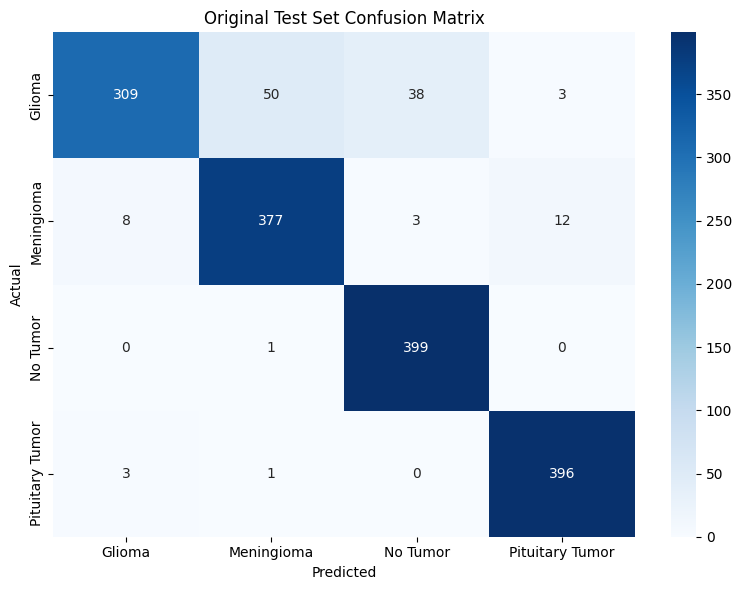

Confusion matrix saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\test_confusion_matrix.png


In [11]:
test_confusion_matrix = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Original Test Set Confusion Matrix")
plt.tight_layout()

TEST_CONFUSION_MATRIX_PATH = (
    RESULTS_FOLDER
    / "test_confusion_matrix.png"
)

plt.savefig(
    TEST_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved to:",
    TEST_CONFUSION_MATRIX_PATH
)

In [12]:
test_image_paths = [
    path
    for path, _
    in test_dataset.samples
]

test_results = pd.DataFrame({
    "Image": [
        Path(path).name
        for path in test_image_paths
    ],

    "Image_Path": test_image_paths,

    "Actual": [
        class_names[label]
        for label in true_labels
    ],

    "Predicted": [
        class_names[prediction]
        for prediction in predicted_labels
    ],

    "Confidence": prediction_confidences
})

test_results["Correct"] = (
    test_results["Actual"]
    == test_results["Predicted"]
)

test_results.head(20)

,Image,Image_Path,Actual,Predicted,Confidence,Correct
0,Te-gl_1.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.636696,False
1,Te-gl_10.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.999970,True
2,Te-gl_100.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.999021,True
3,Te-gl_101.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.984951,True
4,Te-gl_102.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.987939,False
5,Te-gl_103.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.963761,False
6,Te-gl_104.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.719462,False
7,Te-gl_105.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.999956,True
8,Te-gl_106.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.962430,False
9,Te-gl_107.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.999998,True


In [13]:
probabilities_dataframe = pd.DataFrame(
    all_probabilities,
    columns=[
        "Glioma_Probability",
        "Meningioma_Probability",
        "No_Tumor_Probability",
        "Pituitary_Probability"
    ]
)

test_results = pd.concat(
    [
        test_results.reset_index(drop=True),
        probabilities_dataframe.reset_index(drop=True)
    ],
    axis=1
)

test_results.head()

,Image,Image_Path,Actual,Predicted,Confidence,Correct,Glioma_Probability,Meningioma_Probability,No_Tumor_Probability,Pituitary_Probability
0,Te-gl_1.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.636696,False,0.000586,6.366964e-01,0.362361,3.560889e-04
1,Te-gl_10.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.999970,True,0.999970,7.871341e-08,0.000030,4.435823e-07
2,Te-gl_100.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.999021,True,0.999021,5.021540e-07,0.000976,2.489671e-06
3,Te-gl_101.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Glioma,0.984951,True,0.984951,1.441610e-02,0.000354,2.794461e-04
4,Te-gl_102.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.987939,False,0.001783,1.520197e-04,0.987939,1.012588e-02


In [14]:
TEST_RESULTS_PATH = (
    RESULTS_FOLDER
    / "test_validation_results.csv"
)

test_results.to_csv(
    TEST_RESULTS_PATH,
    index=False
)

print(
    "Test predictions saved to:",
    TEST_RESULTS_PATH
)

Test predictions saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\test_validation_results.csv


In [15]:
incorrect_test_results = test_results[
    test_results["Correct"] == False
].copy()

incorrect_test_results

,Image,Image_Path,Actual,Predicted,Confidence,Correct,Glioma_Probability,Meningioma_Probability,No_Tumor_Probability,Pituitary_Probability
0,Te-gl_1.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.636696,False,5.863779e-04,0.636696,0.362361,0.000356
4,Te-gl_102.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.987939,False,1.782651e-03,0.000152,0.987939,0.010126
5,Te-gl_103.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.963761,False,2.840005e-02,0.007319,0.963761,0.000520
6,Te-gl_104.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.719462,False,2.770071e-01,0.719462,0.000769,0.002762
8,Te-gl_106.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.962430,False,3.720494e-06,0.962430,0.037553,0.000014
...,...,...,...,...,...,...,...,...,...,...
837,Te-no_132.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,No Tumor,Meningioma,0.654014,False,4.652884e-09,0.654014,0.345863,0.000122
1322,Te-pi_209.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Pituitary Tumor,Glioma,0.859463,False,8.594632e-01,0.040682,0.000030,0.099825
1358,Te-pi_241.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Pituitary Tumor,Glioma,0.867999,False,8.679989e-01,0.003340,0.000038,0.128623
1375,Te-pi_257.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Pituitary Tumor,Glioma,0.841841,False,8.418413e-01,0.051658,0.000063,0.106438


In [16]:
incorrect_test_results.sort_values(
    by="Confidence",
    ascending=False
)

,Image,Image_Path,Actual,Predicted,Confidence,Correct,Glioma_Probability,Meningioma_Probability,No_Tumor_Probability,Pituitary_Probability
365,Te-gl_68.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,1.000000,False,2.394068e-10,1.000000e+00,5.989684e-12,2.978348e-09
177,Te-gl_259.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.999996,False,3.341648e-06,3.019159e-07,9.999958e-01,4.459986e-07
117,Te-gl_204.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,No Tumor,0.999996,False,3.341648e-06,3.019159e-07,9.999958e-01,4.459986e-07
195,Te-gl_275.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.999991,False,7.815621e-06,9.999913e-01,4.532609e-08,7.774240e-07
11,Te-gl_109.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.999987,False,9.348039e-11,9.999865e-01,4.531114e-10,1.342285e-05
...,...,...,...,...,...,...,...,...,...,...
369,Te-gl_71.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.554393,False,4.453577e-01,5.543928e-01,2.396079e-04,9.887479e-06
134,Te-gl_22.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Meningioma,0.538157,False,3.183130e-01,5.381573e-01,6.928622e-02,7.424353e-02
126,Te-gl_212.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Pituitary Tumor,0.528833,False,4.883987e-03,4.662791e-01,3.544659e-06,5.288333e-01
192,Te-gl_272.jpg,c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI...,Glioma,Pituitary Tumor,0.528833,False,4.883987e-03,4.662791e-01,3.544659e-06,5.288333e-01


In [17]:
INCORRECT_TEST_RESULTS_PATH = (
    RESULTS_FOLDER
    / "test_incorrect_predictions.csv"
)

incorrect_test_results.to_csv(
    INCORRECT_TEST_RESULTS_PATH,
    index=False
)

print(
    "Incorrect predictions saved to:",
    INCORRECT_TEST_RESULTS_PATH
)

Incorrect predictions saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\test_incorrect_predictions.csv


In [18]:
test_summary = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Correct Predictions",
        "Incorrect Predictions",
        "Accuracy"
    ],

    "Value": [
        len(true_labels),
        correct_predictions,
        incorrect_predictions,
        test_accuracy
    ]
})

TEST_SUMMARY_PATH = (
    RESULTS_FOLDER
    / "test_evaluation_summary.csv"
)

test_summary.to_csv(
    TEST_SUMMARY_PATH,
    index=False
)

print(
    "Test summary saved to:",
    TEST_SUMMARY_PATH
)

test_summary

Test summary saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\test_evaluation_summary.csv


,Metric,Value
0,Total Images,1600.000000
1,Correct Predictions,1481.000000
2,Incorrect Predictions,119.000000
3,Accuracy,0.925625
